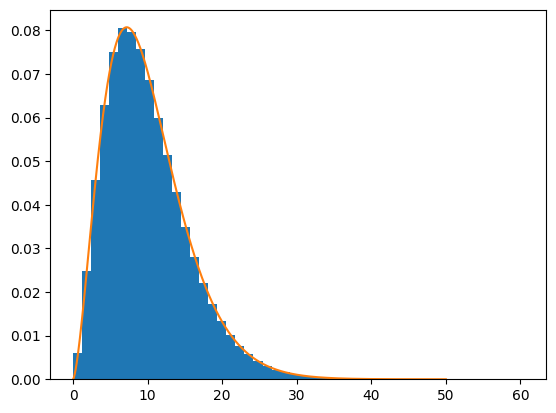

In [ ]:
import numpy as np
from scipy.stats import ncx2
import matplotlib.pyplot as plt
from scipy.special import iv
# Define the parameters
d = 5  # Degrees of freedom
lambda_ = 5  # Non-centrality parameter
a = 0  # Left truncation
b = 50  # Right truncation
ngrid = 2024  # Number of grid intervals

# Define the grid
deltax = (b - a) / ngrid  # Grid step
x = np.arange(a, b + deltax, deltax)  # Equivalent to MATLAB's colon operator

# Compute the PDF and CDF
f = ncx2.pdf(x, d, lambda_)  # PDF

# Sampling the non-central chi-squared distribution
n_samples = 10**6  # Number of samples
samples = ncx2.rvs(d, lambda_, size=n_samples)  # Random sampling

plt.figure(1)
plt.hist(samples,bins=50,density=True)
plt.plot(x,f)
plt.show()

2025
[0.00000000e+00 4.23820949e-05 1.19866895e-04 ... 2.25334239e-06
 2.23498425e-06 0.00000000e+00]


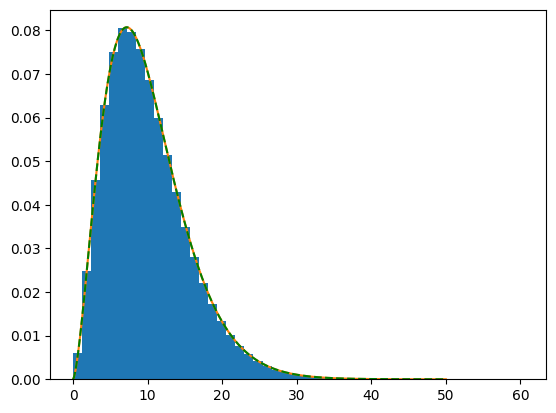

ValueError: x and y must have same first dimension, but have shapes (2023,) and (2025,)

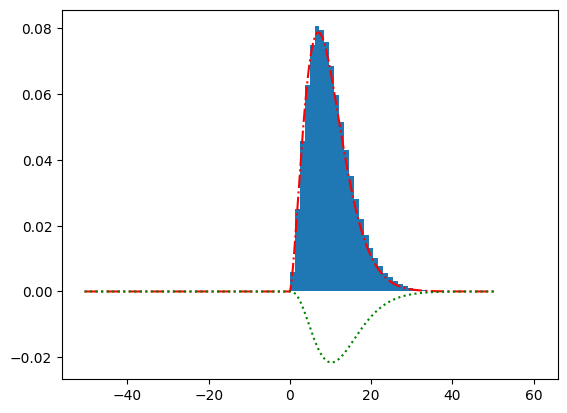

In [ ]:
import numpy as np
from numpy.fft import *
import matplotlib.pyplot as plt



k = d

def bpdf(u):
    bessl_func = iv(k/2-1,np.sqrt(lambda_*u))
    pdf = 1/2 * np.exp(-(u+lambda_)/2) * ((u/lambda_)**(k/4 - 1/2)) * bessl_func
    return pdf


pdf_bes = np.zeros_like(x)
print(len(pdf_bes))
for i in range(ngrid):
    pdf_bes[i] = bpdf(x[i])
    
print(pdf_bes)
plt.figure(2)
plt.hist(samples,bins=50,density=True)
plt.plot(x,f)
plt.plot(x,pdf_bes, 'g--')
plt.show()

# terrible style - NO GLOBAL VARIABLES!


N = 2024
Dx = 0.05
Lx = N*Dx
Dxi = 2*np.pi/Lx
Lxi = N*Dxi
x = Dx*np.arange(-N/2, N/2)
xi = Dxi*np.arange(-N/2, N/2)


# Parameters
k = 5  # degrees of freedom
lambda_ = 5  # non-centrality parameter

Fa = np.divide(np.exp(np.divide(1j*lambda_*xi,1-2j*xi)), pow(1-2j*xi,k/2))

fn = fftshift(fft(ifftshift(Fa)))/Lx


plt.figure(1)
plt.plot(x, np.real(fn),  linestyle='-.', color="r", label='Re(fn)')
plt.plot(x, np.imag(fn),  linestyle=':', color="g", label='Im(fn)')
plt.hist(samples,bins=50,density=True)
plt.plot(x,f)
#plt.plot(x, fa, linestyle='solid', color="y", label='fa')
plt.xlabel('xi')
plt.ylabel('F')
plt.legend()
plt.axis([-50, 50, 0, 0.1])
plt.show()


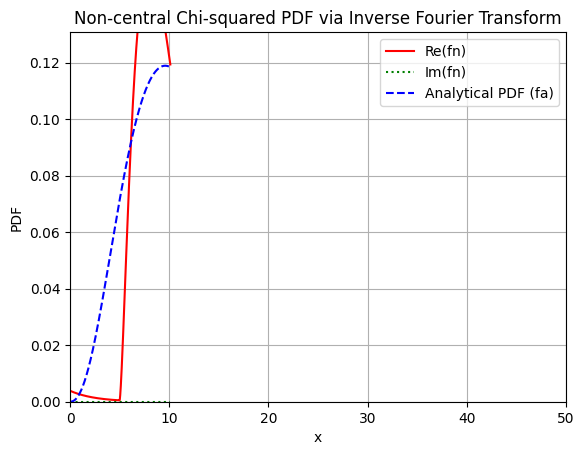

In [163]:
import numpy as np
from numpy.fft import fft, ifft, fftshift, ifftshift
import matplotlib.pyplot as plt
from scipy.special import iv

# Original parameters and grids from your code
N = 2024
Dx = 0.01
Lx = N * Dx
Dxi = 2 * np.pi / Lx
x = Dx * np.arange(-N/2, N/2)
xi = Dxi * np.arange(-N/2, N/2)

# Non-central chi-squared parameters
k = 5  # degrees of freedom
lambda_param = 5  # non-centrality parameter

# Analytical PDF fa(x)
def analytical_pdf(x, k, lambda_param):
    pdf = np.zeros_like(x)
    x_pos = x[x >= 0]
    sqrt_lambda_x = np.sqrt(lambda_param * x_pos)
    bessel_term = iv(k / 2 - 1, sqrt_lambda_x)
    pdf_pos = 0.5 * np.exp(-0.5 * (x_pos + lambda_param)) * ((x_pos / lambda_param) ** (k / 2 - 1)) * bessel_term
    pdf[x >= 0] = pdf_pos
    return pdf

fa = analytical_pdf(x, k, lambda_param)

# Characteristic function Fa(xi) using the correct equation
Fa = np.exp(1j * lambda_param * xi) / (1 - 2j * xi) ** (k / 2)

# Compute the inverse Fourier transform to get the PDF (fn)
Fn = fftshift(ifft(ifftshift(fa))) * Lx
fn = fftshift(fft(ifftshift(Fa))) / Lx  # Using fft as inverse Fourier transform

# Plotting the results
plt.figure()
plt.plot(x, np.real(fn), linestyle='-', color="r", label='Re(fn)')
plt.plot(x, np.imag(fn), linestyle=':', color="g", label='Im(fn)')
plt.plot(x, fa, linestyle='--', color="b", label='Analytical PDF (fa)')
plt.xlabel('x')
plt.ylabel('PDF')
plt.legend()
plt.axis([0, 50, 0, max(fa)*1.1])
plt.title('Non-central Chi-squared PDF via Inverse Fourier Transform')
plt.grid(True)
plt.show()